# Elbow Method & Silhouette Score for K selection 

- Customer Segmentation Dataset

### Step 1: Import necessary libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

### Step 2: Load and preprocess the data

In [2]:
data = pd.read_csv('customer_segmentation.csv')
data.head()

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
1,462643,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4,A
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
4,462669,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6,A


In [3]:
# Drop non-numeric and irrelevant columns (e.g., ID, Gender, etc.)
data = data.drop(columns=['ID', 'Gender', 'Ever_Married', 'Graduated', 'Profession', 'Spending_Score', 
                          'Var_1', 'Segmentation'])


In [4]:
data.head()

,Age,Work_Experience,Family_Size
0,22,1.0,4.0
1,38,NaN,3.0
2,67,1.0,1.0
3,67,0.0,2.0
4,40,NaN,6.0


In [5]:
# Drop rows with missing values (NaN)
data = data.dropna()

### Step 3: Scale the data (if needed)

In [6]:
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

### Step 4: Apply K-Means for Various K Values


In [7]:
inertia_values = []
silhouette_scores = []
K_range = range(2, 11)  # You can adjust the range as needed

for K in K_range:
    kmeans = KMeans(n_clusters=K, random_state=42)
    kmeans.fit(data_scaled)
    
    # Inertia (within-cluster sum of squares)
    inertia_values.append(kmeans.inertia_)
    
    # Silhouette Score
    silhouette = silhouette_score(data_scaled, kmeans.labels_)
    silhouette_scores.append(silhouette)

### Step 5: Elbow Method

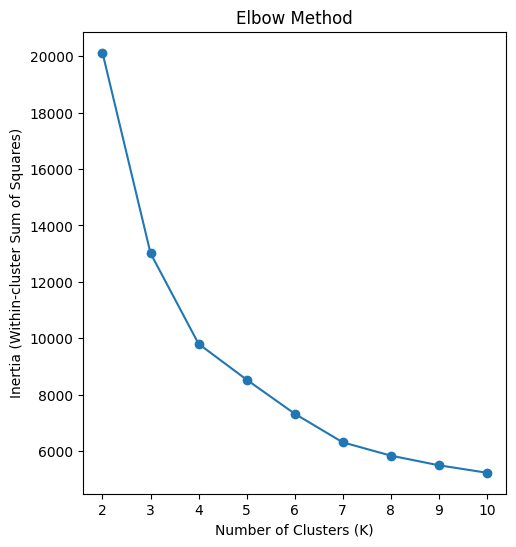

In [8]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(K_range, inertia_values, marker='o', linestyle='-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Within-cluster Sum of Squares)')
plt.title('Elbow Method')
plt.show()

### Step 6: Silhouette Score

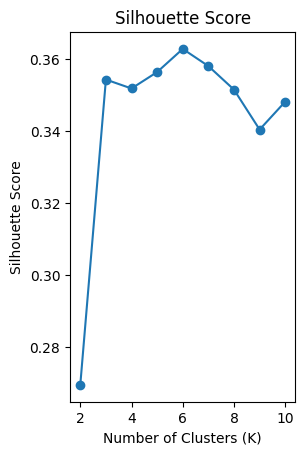

In [9]:
plt.subplot(1, 2, 2)
plt.plot(K_range, silhouette_scores, marker='o', linestyle='-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score')
plt.show()

### Step 8: Interpretation

In [10]:
# Find the K value from the Elbow Method
elbow_K = 3  # Replace with the K value where you observe the "elbow" in the plot

# Find the K value from the Silhouette Score
silhouette_K = 4  # Replace with the K value that maximizes the Silhouette Score

# Print the selected K values
print(f"Selected K value from Elbow Method: {elbow_K}")
print(f"Selected K value from Silhouette Score: {silhouette_K}")


Selected K value from Elbow Method: 3
Selected K value from Silhouette Score: 4


In [11]:
'''You can use either the K value from the Elbow Method or the Silhouette Score, based on your preference and
the characteristics of the dataset'''

'You can use either the K value from the Elbow Method or the Silhouette Score, based on your preference and\nthe characteristics of the dataset'


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


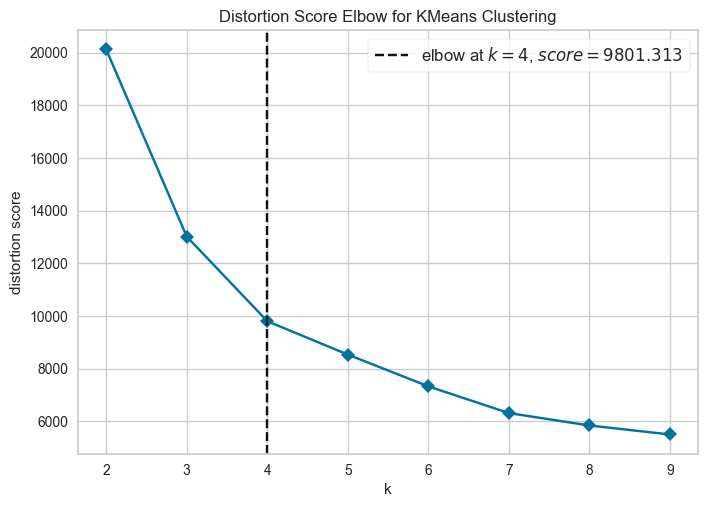

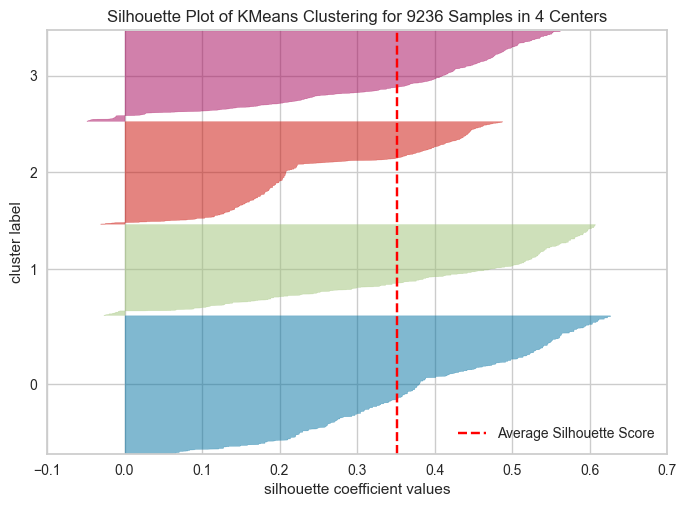

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 9236 Samples in 4 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [12]:
%pip install -q "scikit-learn<1.6" "yellowbrick>=1.5"

# Plot Elbow Curve & Silhouette Score using Yellowbrick
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

model = KMeans(n_clusters=4, random_state=42)
visualizer = KElbowVisualizer(
    model,
    k=(2, 10),
    metric="distortion",
    timings=False
)
visualizer.fit(data_scaled)
visualizer.show()

silhouette_visualizer = SilhouetteVisualizer(
    KMeans(n_clusters=4, random_state=42),
    colors="yellowbrick"
)
silhouette_visualizer.fit(data_scaled)
silhouette_visualizer.show()
 
 
 

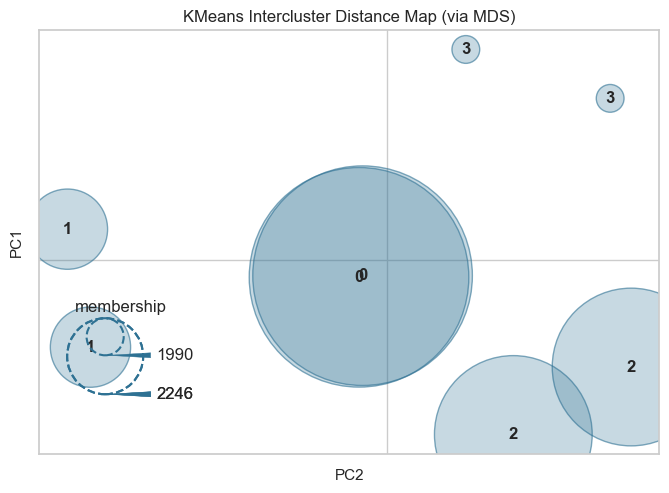

<Axes: title={'center': 'KMeans Intercluster Distance Map (via MDS)'}, xlabel='PC2', ylabel='PC1'>

In [15]:
from yellowbrick.cluster import InterclusterDistance

# Reuse the existing model defined earlier
visualizer = InterclusterDistance(model)

# Visualize intercluster distances
visualizer.fit(data_scaled)
# NumPy 2.x removed Yellowbrick's deprecated `interpolation` argument.
_original_percentile = np.percentile

def _percentile_compat(a, q, *args, interpolation=None, **kwargs):
    if interpolation is not None:
        kwargs["method"] = interpolation
    return _original_percentile(a, q, *args, **kwargs)

np.percentile = _percentile_compat

# Refit after applying the compatibility fix
visualizer.fit(data_scaled)
visualizer.show()

In [16]:
model = KMeans(n_clusters=4, random_state=42)
silhouette_visualizer = SilhouetteVisualizer(model)

In [17]:
# Select K based on the highest silhouette score
final_K = K_range[np.argmax(silhouette_scores)]
print(f"Selected K: {final_K}")

# Fit the final K-Means model
final_model = KMeans(n_clusters=final_K, random_state=42, n_init=10)
data["Cluster"] = final_model.fit_predict(data_scaled)

# Examine cluster sizes and feature averages
cluster_summary = data.groupby("Cluster").agg(
    Size=("Cluster", "size"),
    Age=("Age", "mean"),
    Work_Experience=("Work_Experience", "mean"),
    Family_Size=("Family_Size", "mean")
)

cluster_summary

Selected K: 6


,Size,Age,Work_Experience,Family_Size
Cluster,,,,
0,1753,27.610382,0.911010,3.757558
1,1521,70.692308,0.903353,1.803419
2,1489,51.325722,0.979852,3.817999
3,1840,37.794022,8.419022,2.320652
4,2057,39.491006,1.067574,1.582402
5,576,31.850694,3.487847,6.442708


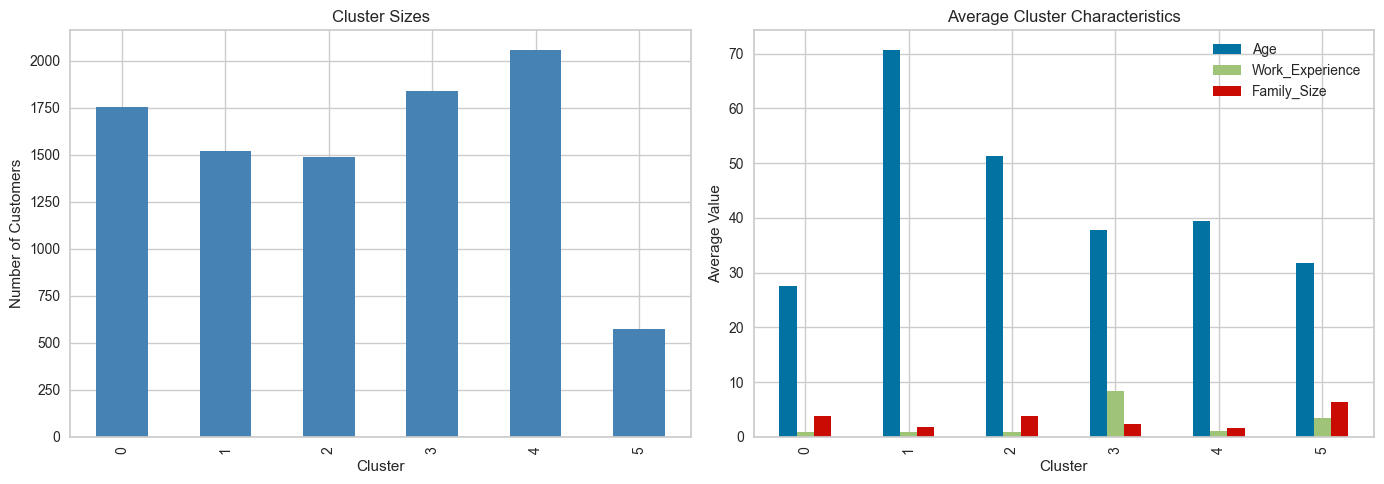

,Size,Age,Work_Experience,Family_Size
Cluster,,,,
0,1753,27.610382,0.911010,3.757558
1,1521,70.692308,0.903353,1.803419
2,1489,51.325722,0.979852,3.817999
3,1840,37.794022,8.419022,2.320652
4,2057,39.491006,1.067574,1.582402
5,576,31.850694,3.487847,6.442708


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cluster sizes
cluster_summary["Size"].plot(
    kind="bar",
    ax=axes[0],
    color="steelblue",
    title="Cluster Sizes"
)
axes[0].set_xlabel("Cluster")
axes[0].set_ylabel("Number of Customers")

# Cluster profiles
cluster_summary[["Age", "Work_Experience", "Family_Size"]].plot(
    kind="bar",
    ax=axes[1],
    title="Average Cluster Characteristics"
)
axes[1].set_xlabel("Cluster")
axes[1].set_ylabel("Average Value")

plt.tight_layout()
plt.show()

cluster_summary